# Stage 2: Classical Bank Scorecard (WOE + LR)

**Objective**: Build an industry-standard credit scorecard using Weight of Evidence (WOE) encoding and Logistic Regression.

**Pipeline**: WOE Binning → IV Filter → WOE Transform → VIF/Corr Filter → LR → Score Scale (300-850)

**Output**: Scorecard table, KS/AUC metrics, score distribution plots, saved model.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('muted')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'results' / 'analysis_reports'
MODEL_DIR = PROJECT_ROOT / 'results' / 'models'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Report dir:   {REPORT_DIR}')

Project root: /Users/siwei_wang/Documents/project_proposals_financial
Data dir:     /Users/siwei_wang/Documents/project_proposals_financial/data/processed
Report dir:   /Users/siwei_wang/Documents/project_proposals_financial/results/analysis_reports


In [2]:
# Load processed data
train = pd.read_parquet(DATA_DIR / 'train.parquet')
val = pd.read_parquet(DATA_DIR / 'val.parquet')
test = pd.read_parquet(DATA_DIR / 'test.parquet')

print(f'Train: {train.shape[0]:,} rows, {train.shape[1]} cols, bad_rate={train["is_bad"].mean():.2%}')
print(f'Val:   {val.shape[0]:,} rows, {val.shape[1]} cols, bad_rate={val["is_bad"].mean():.2%}')
print(f'Test:  {test.shape[0]:,} rows, {test.shape[1]} cols, bad_rate={test["is_bad"].mean():.2%}')

Train: 451,060 rows, 68 cols, bad_rate=16.96%
Val:   375,546 rows, 68 cols, bad_rate=20.19%
Test:  293,105 rows, 68 cols, bad_rate=23.29%


---
# Part 1: Train Scorecard
---

In [3]:
from src.models.scorecard import Scorecard

sc = Scorecard(
    base_score=600,
    base_odds=50,
    pdo=20,
    iv_threshold=0.02,
    vif_threshold=5.0,
    corr_threshold=0.7,
    max_bins=6,
    min_bin_size=0.02,
    lr_C=1.0,
)

sc.fit(train, val, target='is_bad')

Starting scorecard with 62 features (7 categorical, 55 numeric)
Successfully binned 62/62 features
IV filter (threshold=0.02): kept 34, dropped 28
  Dropped (low IV): num_op_rev_tl (IV=0.0165)
  Dropped (low IV): num_actv_bc_tl (IV=0.0159)
  Dropped (low IV): num_sats (IV=0.0149)
  Dropped (low IV): emp_length (IV=0.0133)
  Dropped (low IV): mo_sin_old_il_acct (IV=0.0129)
  ... and 23 more
Adjacent-bin merge test: 1 bin pairs flagged in 1 features
  verification_status: p=0.505  ['Source Verified']  |  ['Verified']
WOE consistency check: all features stable (OK)
VIF filter (threshold=5.0): kept 29, dropped 5
Correlation filter (threshold=0.7): kept 26, dropped 3
Final features for LR: 26

Scorecard complete.
  Features: 26
  Train score range: [473, 614]


---
# Part 2: Model Evaluation
---

In [4]:
from src.evaluation.metrics import scorecard_report, ks_score, gini_score, auc_score, pr_auc

# Predict on all sets
y_train_true = train['is_bad'].values
y_val_true = val['is_bad'].values
y_test_true = test['is_bad'].values

y_train_pred = sc.predict_proba(train)
y_val_pred = sc.predict_proba(val)
y_test_pred = sc.predict_proba(test)

y_train_score = sc.predict_score(train)
y_val_score = sc.predict_score(val)
y_test_score = sc.predict_score(test)

# Reports
report_train = scorecard_report(y_train_true, y_train_pred, y_train_score, 'Train')
report_val = scorecard_report(y_val_true, y_val_pred, y_val_score, 'Val')
report_test = scorecard_report(y_test_true, y_test_pred, y_test_score, 'Test')

print('=' * 70)
print(f'{"STAGE 2 — SCORECARD RESULTS":^70}')
print('=' * 70)
for r in [report_train, report_val, report_test]:
    print(f'\n--- {r["label"]} ---')
    print(f'  AUC:     {r["AUC"]:.4f}')
    print(f'  KS:      {r["KS"]:.4f}')
    print(f'  Gini:    {r["Gini"]:.4f}')
    print(f'  PR-AUC:  {r["PR_AUC"]:.4f}')
    print(f'  Default Rate: {r["default_rate"]:.2%}')
    print(f'  Score Bands:')
    for band, info in r.get('score_bands', {}).items():
        print(f'    {band}: n={info["count"]:,}  default_rate={info["default_rate"]:.2%}')

                     STAGE 2 — SCORECARD RESULTS                      

--- Train ---
  AUC:     0.6991
  KS:      0.2887
  Gini:    0.3983
  PR-AUC:  0.3156
  Default Rate: 16.96%
  Score Bands:
    450-520: n=99,115  default_rate=32.49%
    520-580: n=338,515  default_rate=12.98%
    580-640: n=13,430  default_rate=2.53%

--- Val ---
  AUC:     0.7290
  KS:      0.3321
  Gini:    0.4580
  PR-AUC:  0.4055
  Default Rate: 20.19%
  Score Bands:
    450-520: n=76,417  default_rate=42.05%
    520-580: n=285,623  default_rate=15.16%
    580-640: n=13,506  default_rate=2.64%

--- Test ---
  AUC:     0.7040
  KS:      0.2946
  Gini:    0.4079
  PR-AUC:  0.4110
  Default Rate: 23.29%
  Score Bands:
    450-520: n=54,682  default_rate=44.05%
    520-580: n=227,617  default_rate=19.22%
    580-640: n=10,806  default_rate=3.88%


---
# Part 3: ROC Curves
---

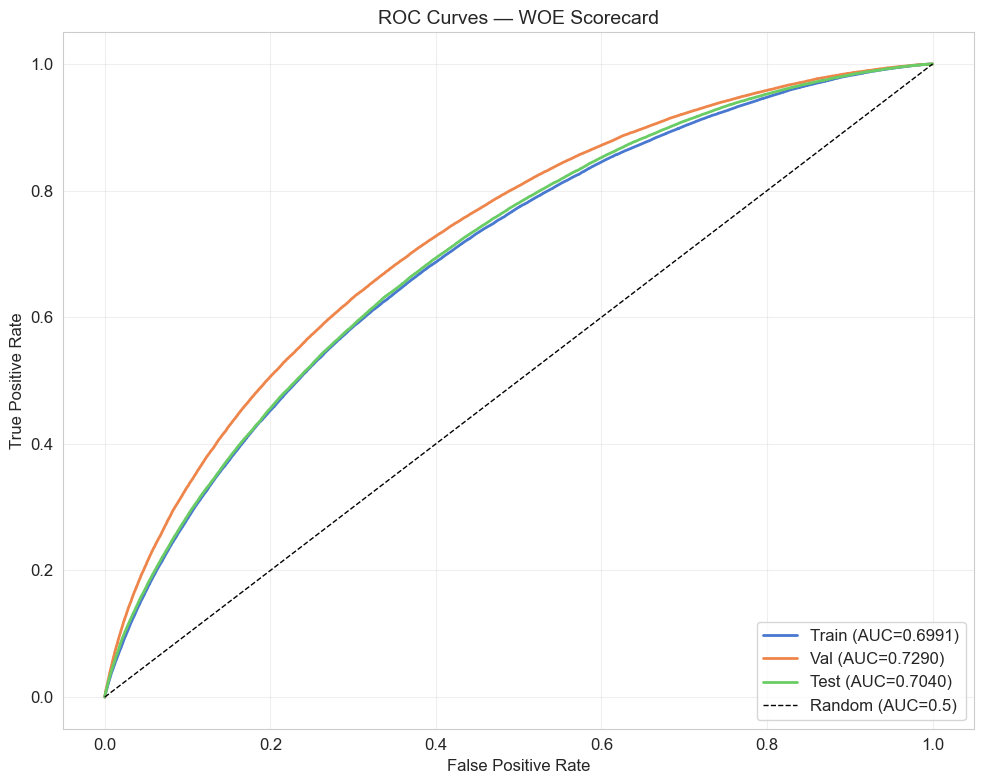

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(10, 8))

for name, y_true, y_pred in [
    ('Train', y_train_true, y_train_pred),
    ('Val', y_val_true, y_val_pred),
    ('Test', y_test_true, y_test_pred),
]:
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — WOE Scorecard')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_DIR / '11_scorecard_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 4: Score Distribution
---

In [6]:
from src.evaluation.calibration import psi, score_distribution_stats

psi_train_test = psi(y_train_score, y_test_score, bins=10)
psi_train_val = psi(y_train_score, y_val_score, bins=10)

print(f'PSI (Train vs Test): {psi_train_test:.4f}')
print(f'PSI (Train vs Val):  {psi_train_val:.4f}')

stats = score_distribution_stats(y_train_score, y_test_score, y_val_score)
print(f'\nScore Distribution Stats:')
print(stats.to_string(index=False))

PSI (Train vs Test): 0.0101
PSI (Train vs Val):  0.0094

Score Distribution Stats:
dataset  count       mean       std        min         p5        p25     median        p75        p95        max
  Train 451060 538.239151 22.213508 472.503619 501.969450 522.262594 538.008345 553.832924 575.608607 614.317197
   Test 293105 540.334974 22.153946 472.969766 503.710948 524.810320 539.826275 556.074603 577.351468 613.352550
    Val 375546 539.870571 22.982361 474.621757 500.871754 523.763951 539.776406 556.768802 577.259557 611.331096


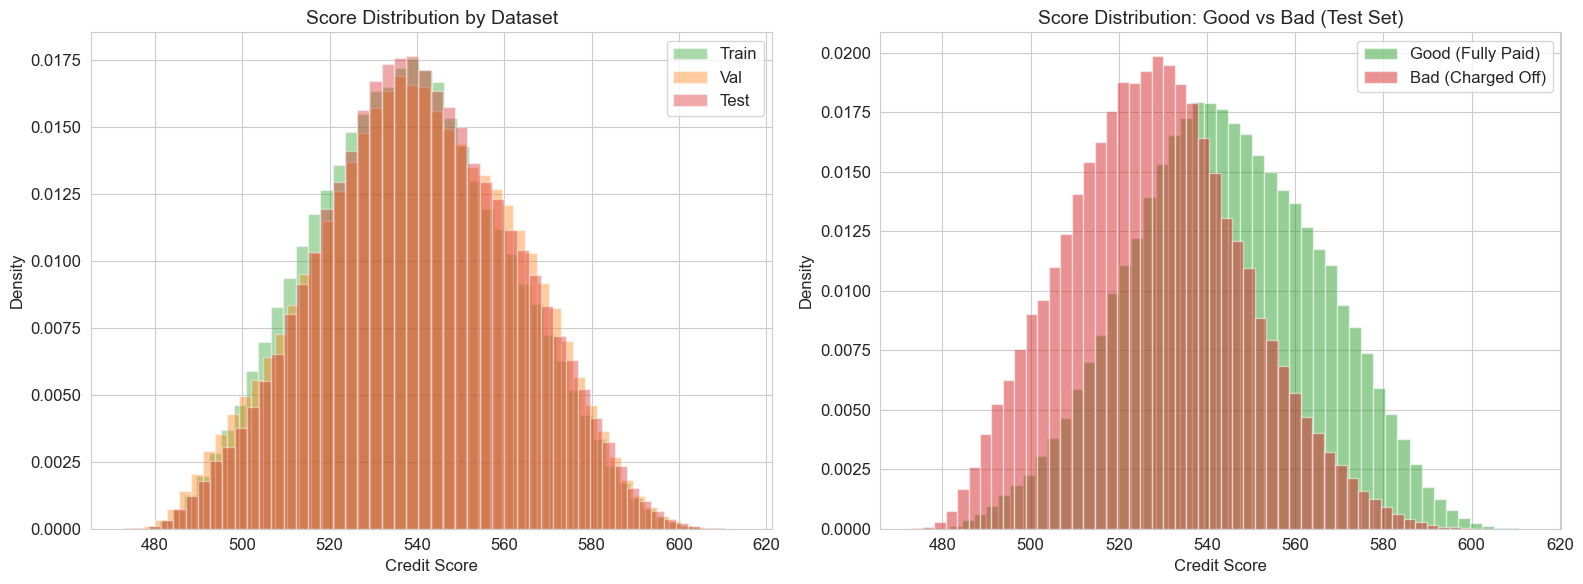

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Score histogram
ax = axes[0]
for scores, name, color in [
    (y_train_score, 'Train', '#2ca02c'),
    (y_val_score, 'Val', '#ff7f0e'),
    (y_test_score, 'Test', '#d62728'),
]:
    ax.hist(scores, bins=50, alpha=0.4, density=True, label=name, color=color)
ax.set_xlabel('Credit Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Dataset')
ax.legend()

# Score by good/bad
ax = axes[1]
for mask, name, color in [
    (y_test_true == 0, 'Good (Fully Paid)', '#2ca02c'),
    (y_test_true == 1, 'Bad (Charged Off)', '#d62728'),
]:
    ax.hist(y_test_score[mask], bins=50, alpha=0.5, density=True, label=name, color=color)
ax.set_xlabel('Credit Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution: Good vs Bad (Test Set)')
ax.legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / '12_scorecard_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 5: Default Rate by Score Band
---

Default Rate by Score Band (Test):
 score_low  score_high  count  pct  default_rate  cum_pct
       470         510  25914  8.8         50.51      8.8
       510         520  28768  9.8         38.24     18.6
       520         530  41810 14.3         31.27     32.9
       530         540  50941 17.4         24.39     50.3
       540         550  47818 16.3         18.72     66.6
       550         560  38845 13.3         13.81     79.9
       560         570  29501 10.1          9.31     90.0
       570         610  29505 10.1          5.44    100.1


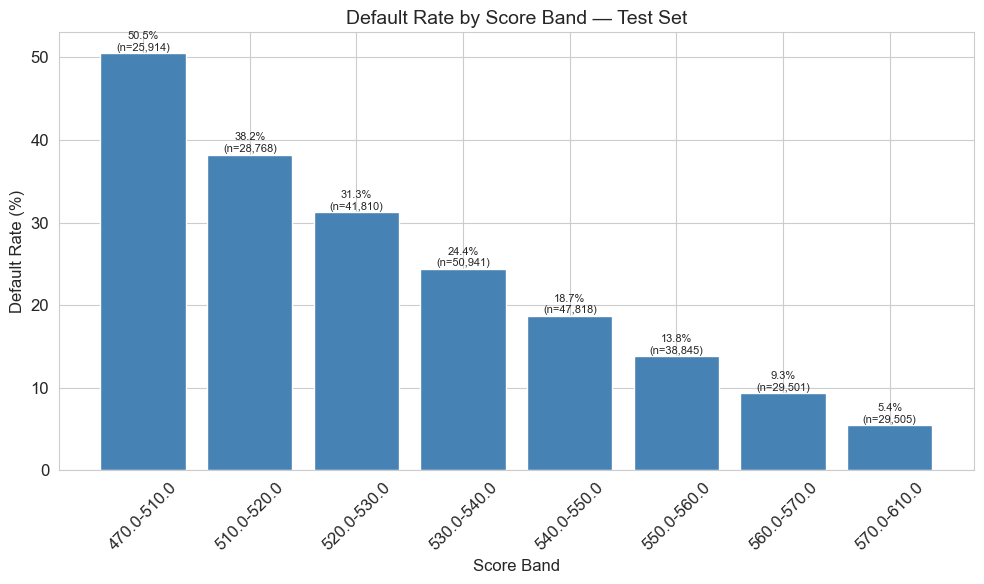

In [8]:
from src.evaluation.calibration import default_rate_by_score_band

band_df = default_rate_by_score_band(y_test_score, y_test_true, bins=8)
print('Default Rate by Score Band (Test):')
print(band_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    [f'{r["score_low"]}-{r["score_high"]}' for _, r in band_df.iterrows()],
    band_df['default_rate'],
    color='steelblue',
    edgecolor='white'
)
ax.set_xlabel('Score Band')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Score Band — Test Set')
ax.tick_params(axis='x', rotation=45)
for bar, rate, count in zip(bars, band_df['default_rate'], band_df['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%\n(n={count:,})', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(REPORT_DIR / '13_scorecard_default_rate_bands.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 6: Feature Importance
---

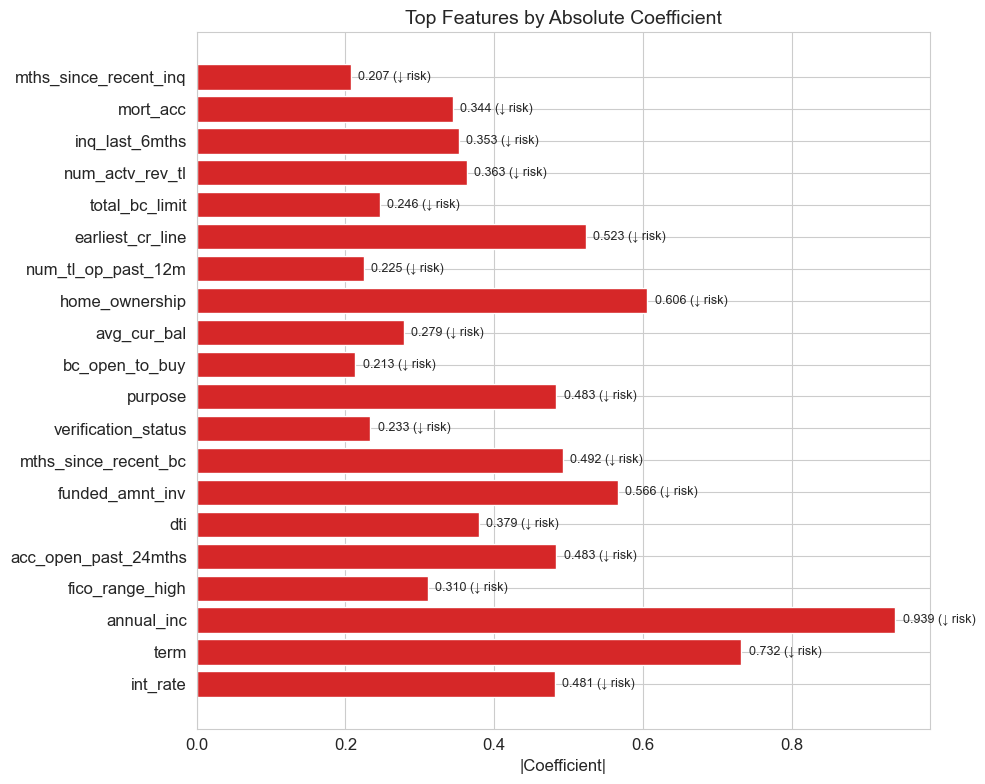


Full importance for 26 features:
                  feature  coefficient  abs_coef        iv  importance
0                int_rate    -0.480963  0.480963  0.675028    0.324664
1                    term    -0.732044  0.732044  0.397886    0.291270
2              annual_inc    -0.938873  0.938873  0.066836    0.062750
3         fico_range_high    -0.310480  0.310480  0.194179    0.060289
4    acc_open_past_24mths    -0.483112  0.483112  0.099158    0.047905
5                     dti    -0.379450  0.379450  0.100386    0.038091
6         funded_amnt_inv    -0.566090  0.566090  0.055100    0.031192
7    mths_since_recent_bc    -0.491758  0.491758  0.042053    0.020680
8     verification_status    -0.233445  0.233445  0.088350    0.020625
9                 purpose    -0.483180  0.483180  0.038833    0.018763
10         bc_open_to_buy    -0.213387  0.213387  0.087906    0.018758
11            avg_cur_bal    -0.278748  0.278748  0.067151    0.018718
12         home_ownership    -0.605592  0.6

In [9]:
importance_df = sc.get_feature_importance()
top_features = importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
# Use .to_numpy() to avoid index-order issues with reversed()
coefs = top_features['coefficient'].to_numpy()[::-1]
abs_coefs = top_features['abs_coef'].to_numpy()[::-1]
feat_names = top_features['feature'].to_numpy()[::-1]
colors = ['#d62728' if c < 0 else '#2ca02c' for c in coefs]
ax.barh(range(len(feat_names)), abs_coefs, color=colors, edgecolor='white')
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels(feat_names)
ax.invert_yaxis()
ax.set_xlabel('|Coefficient|')
ax.set_title('Top Features by Absolute Coefficient')

for i in range(len(feat_names)):
    direction = '↑ risk' if coefs[i] > 0 else '↓ risk'
    ax.text(abs_coefs[i] + 0.01, i, f"{abs_coefs[i]:.3f} ({direction})",
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORT_DIR / '14_scorecard_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFull importance for {len(importance_df)} features:')
print(importance_df.to_string())

---
# Part 7: Scorecard Table Excerpt
---

In [10]:
# Show top 3 features with full bin details
top3 = importance_df.head(3)['feature'].tolist()
table = sc.scorecard_table_
excerpt = table[table['feature'].isin(top3)]
print('=' * 120)
print(f'{"SCORECARD TABLE — Top 3 Features":^120}')
print('=' * 120)
print(excerpt[['feature', 'bin', 'count', 'event_rate', 'woe', 'coefficient', 'points']].to_string(index=False))
print('\n... (full scorecard has', len(table), 'rows)')

                                            SCORECARD TABLE — Top 3 Features                                            
   feature                  bin  count  event_rate       woe  coefficient  points
  int_rate         (-inf, 9.74)  91014    0.061353  1.139331    -0.480963    15.8
  int_rate        [9.74, 14.48) 175911    0.134079  0.276902    -0.480963     3.8
  int_rate         [14.48, inf) 184135    0.257040 -0.527049    -0.480963    -7.3
  int_rate              Special      0    0.000000  0.000000    -0.480963     0.0
  int_rate              Missing      0    0.000000  0.000000    -0.480963     0.0
annual_inc     (-inf, 60865.00) 218516    0.193226 -0.159279    -0.938873    -4.3
annual_inc [60865.00, 80000.02)  96689    0.165241  0.031276    -0.938873     0.8
annual_inc      [80000.02, inf) 135855    0.134702  0.271544    -0.938873     7.4
annual_inc              Special      0    0.000000  0.000000    -0.938873     0.0
annual_inc              Missing      0    0.000000  0.00000

---
# Part 8: Save Model
---

In [11]:
model_path = MODEL_DIR / 'scorecard_stage2.pkl'
sc.save(model_path)
print(f'Scorecard saved to: {model_path}')
print(f'File size: {model_path.stat().st_size / 1024:.1f} KB')

# Save scorecard table as CSV for inspection
table_path = REPORT_DIR / 'scorecard_table.csv'
sc.scorecard_table_.to_csv(table_path, index=False)
print(f'Scorecard table saved to: {table_path}')

Scorecard saved to: /Users/siwei_wang/Documents/project_proposals_financial/results/models/scorecard_stage2.pkl
File size: 153.4 KB
Scorecard table saved to: /Users/siwei_wang/Documents/project_proposals_financial/results/analysis_reports/scorecard_table.csv


---
# Part 9: Benchmark Comparison
---

In [12]:
print('=' * 70)
print(f'{"BENCHMARK COMPARISON":^70}')
print('=' * 70)
print(f'\n{"Model":<30} {"Test AUC":>10} {"Test KS":>10}')
print('-' * 50)
print(f'{"Stage 1 — Raw LR":<30} {"0.7140":>10} {"---":>10}')
print(f'{"Stage 2 — WOE Scorecard":<30} {report_test["AUC"]:>10.4f} {report_test["KS"]:>10.4f}')
print()

auc_improvement = (report_test['AUC'] - 0.7140) / 0.7140 * 100
print(f'AUC improvement: {auc_improvement:+.1f}% vs Stage 1 baseline')

                         BENCHMARK COMPARISON                         

Model                            Test AUC    Test KS
--------------------------------------------------
Stage 1 — Raw LR                   0.7140        ---
Stage 2 — WOE Scorecard            0.7040     0.2946

AUC improvement: -1.4% vs Stage 1 baseline


---
## Stage 2 Summary

- **Method**: WOE binning → IV filter → VIF/corr filter → Logistic Regression → Score scale
- **Features used**: {len(sc.final_features_)} out of original 89
- **Key metrics**: AUC={report_test['AUC']}, KS={report_test['KS']}, Gini={report_test['Gini']}
- **PSI (Train→Test)**: {psi_train_test:.4f}
- **Model saved**: `results/models/scorecard_stage2.pkl`
- **Scorecard table**: `results/analysis_reports/scorecard_table.csv`